In [1]:
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

from src.model import MultiClass_NN

import joblib

In [2]:
X_train = np.load('data/ready/X_train.npy') 
X_val = np.load('data/ready/X_val.npy')
X_test = np.load('data/ready/X_test.npy')
y_train = np.load('data/ready/y_train.npy')
y_val = np.load('data/ready/y_val.npy')
y_test = np.load('data/ready/y_test.npy')


# Encoder les etiquettes en one-hot pour la classification multiclasse
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_train_one_hot = np.array(one_hot_encoder.fit_transform(y_train.reshape(-1, 1)))
y_val_one_hot = np.array(one_hot_encoder.transform(y_val.reshape(-1, 1)))
y_test_one_hot = np.array(one_hot_encoder.transform(y_test.reshape(-1, 1)))

# Verifier que les tableaux one-hot sont des NumPy arrays
assert isinstance(y_train_one_hot, np.ndarray), "y_train_one_hot must be a numpy array"
assert isinstance (y_val_one_hot, np.ndarray), "y_val_one_hot must be a numpy array"
assert isinstance (y_test_one_hot, np.ndarray), "y_test_one_hot must be a numpy array"


In [3]:
# Predictions et evaluation
label_encoder = joblib.load('artifacts/label_encoder.joblib')

# Creer et entrainer le modele
layer_sizes = [X_train.shape [1], 64, 32, len(label_encoder.classes_)] # 64 et 32 neurones caches, 33 classes


In [ ]:
lrs = [0.01 , 0.05 , 0.8 , 0.1]
lm_regs = [0.0 , 0.1 , 0.15 , 0.2 ]

for lr in lrs :
    for lm_reg in lm_regs:
        print(f"_________testing lr = {lr} , lm reg = {lm_reg}")
        nn = MultiClass_NN(layer_sizes, learning_rate=lr , lambda_reg=lm_reg )
        train_losses, val_losses, train_accuracies, val_accuracies = nn.train (
            X_train, y_train_one_hot, X_val, y_val_one_hot, epochs=51, batch_size=32 
        )
    


In [21]:
nn = MultiClass_NN(layer_sizes, learning_rate=0.05 , lambda_reg=0.15 )
train_losses, val_losses, train_accuracies, val_accuracies = nn.train (
    X_train, y_train_one_hot, X_val, y_val_one_hot, epochs=100, batch_size=32 , lr_e=50 , lr_dv=0.5
)

Epoch 0, Train Loss: 3.5037, Val Loss: 3.4965, Train Acc: 0.0303, Val Acc: 0.0303 , lr = 0.05
Epoch 10, Train Loss: 2.1168, Val Loss: 2.0263, Train Acc: 0.3405, Val Acc: 0.3246 , lr = 0.05
Epoch 20, Train Loss: 0.7592, Val Loss: 1.0382, Train Acc: 0.6952, Val Acc: 0.6516 , lr = 0.05
Epoch 30, Train Loss: 0.5286, Val Loss: 0.5950, Train Acc: 0.8699, Val Acc: 0.8283 , lr = 0.05
Epoch 40, Train Loss: 0.4490, Val Loss: 0.5272, Train Acc: 0.8970, Val Acc: 0.8515 , lr = 0.05
Epoch 50, Train Loss: 0.3742, Val Loss: 0.4589, Train Acc: 0.9251, Val Acc: 0.8842 , lr = 0.025
Epoch 60, Train Loss: 0.3625, Val Loss: 0.4465, Train Acc: 0.9352, Val Acc: 0.8895 , lr = 0.025
Epoch 70, Train Loss: 0.3528, Val Loss: 0.4492, Train Acc: 0.9275, Val Acc: 0.8882 , lr = 0.025
Epoch 80, Train Loss: 0.3465, Val Loss: 0.4474, Train Acc: 0.9263, Val Acc: 0.8865 , lr = 0.025
Epoch 90, Train Loss: 0.3409, Val Loss: 0.4293, Train Acc: 0.9378, Val Acc: 0.8992 , lr = 0.025


In [20]:
y_pred = nn.predict(X_test)
print("\nRapport de classification (Test set) :")
print (classification_report (y_test, y_pred, target_names=label_encoder.classes_))


Rapport de classification (Test set) :
              precision    recall  f1-score   support

          ya       0.94      0.99      0.97       171
         yab       0.83      0.90      0.86       171
        yach       0.94      0.89      0.92       171
         yad       0.95      0.95      0.95       171
        yadd       0.86      0.91      0.88       171
         yae       0.92      0.97      0.94       171
         yaf       0.95      0.94      0.94       171
         yag       0.96      0.93      0.94       171
        yagg       0.96      0.94      0.95       170
        yagh       0.96      0.95      0.95       170
         yah       0.96      0.95      0.96       171
        yahh       0.92      0.93      0.93       171
         yaj       0.94      0.90      0.92       171
         yak       0.90      0.90      0.90       171
        yakk       0.96      0.95      0.96       171
         yal       0.94      0.95      0.95       170
         yam       0.96      0.96      0.

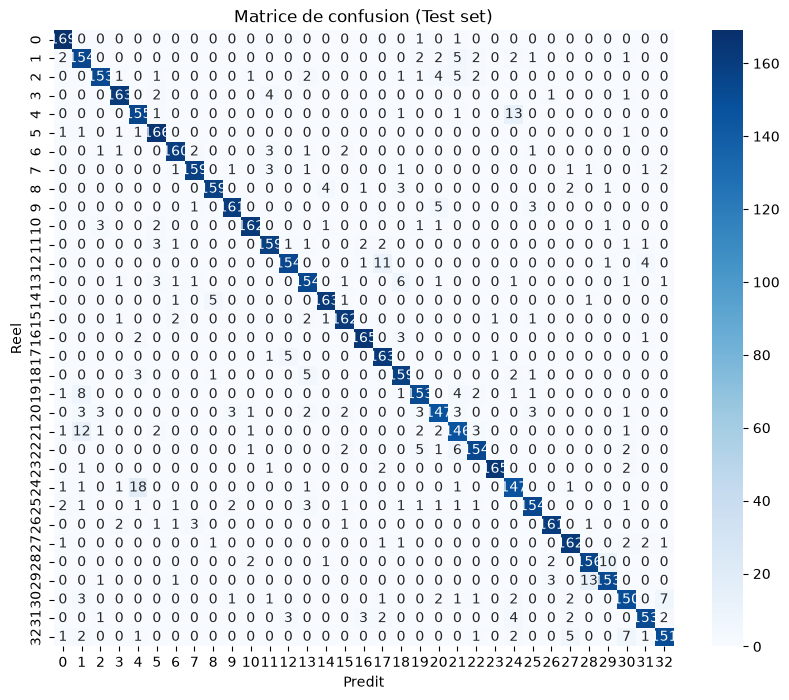

In [21]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap (cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion (Test set)')
plt.xlabel('Predit')
plt.ylabel('Reel')
plt.show()

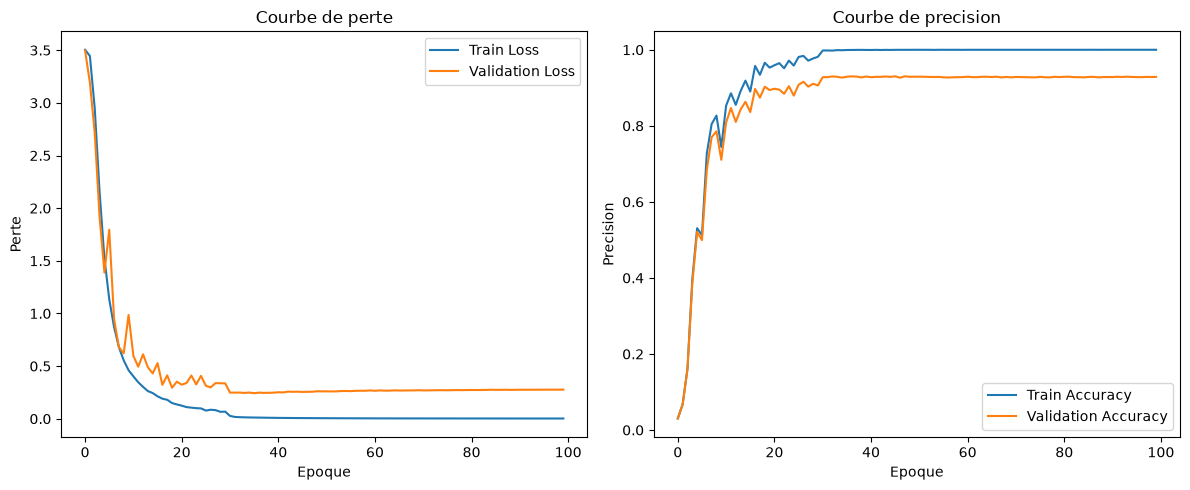

In [15]:
# Courbes de perte et d'accuracy
fig, (ax1, ax2) = plt.subplots (1, 2, figsize=(12, 5))

# Courbe de perte
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_title('Courbe de perte')
ax1.set_xlabel('Epoque')
ax1.set_ylabel('Perte')
ax1.legend ()

# Courbe d'accuracy
ax2.plot(train_accuracies, label='Train Accuracy')
ax2.plot(val_accuracies, label='Validation Accuracy')
ax2.set_title('Courbe de precision')
ax2.set_xlabel('Epoque')
ax2.set_ylabel('Precision')
ax2.legend()

plt.tight_layout()
plt.show()